## Conversion from Keras HGQ2 model to HLS4ML model (Verilog)

Convert the quantized model to HLS (High-Level Synthesis) code for FPGA deployment. Precision is automatically inferred from the HGQ2 model.

In [1]:
import os, subprocess
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Keras 3
import keras

# Package imports
from bedposip.data import load_dataset, preprocess_data

import hls4ml
from hls4ml.model.profiling import numerical, compare

from sklearn.metrics import log_loss, accuracy_score # sklearn has an easy interface for testing
from scipy.special import softmax # log_loss requires probabilities not found in HLS because 'from_logits=True'

PROFILE = False
BUILD_IP = True
BUILD_PYNQ = True
RESET_BUILD = True

I0000 00:00:1782869607.825658 2153594 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Model Loading

In [5]:
model_path = "output/posture_classifier_qat.keras"
model_qat = keras.models.load_model(model_path)
model_qat.summary()

I0000 00:00:1782869610.283764 2153594 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1056 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 16)       │           646 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │         9,286 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        13,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (QMaxPooling2D)          │ (None, 1, 1, 24)       │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 12)             │         1,158 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1                      │ (None, 12)             │           126 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 24)             │         1,158 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2                      │ (None, 24)             │           246 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,976 (242.02 KB)

 Trainable params: 20,058 (78.35 KB)

 Non-trainable params: 6,800 (6.96 KB)

 Optimizer params: 40,118 (156.71 KB)

In [6]:
# from hgq.utils import trace_minmax

# ebops = trace_minmax(model_qat, X_test, verbose=True)

# lut_pred = np.exp(0.985 * np.log(ebops))
# dsp_pred = (ebops - lut_pred) / 55

# print("Resource Estimation Report")
# print("="*40)
# print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

In [7]:
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

I0000 00:00:1782869615.041116 2153658 service.cc:153] XLA service 0x7fd53c040870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782869615.041130 2153658 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1782869615.125811 2153658 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782869615.399143 2153658 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1782869618.839323 2153658 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Keras  model evaluation 	 Loss: 0.30 	 Accuracy: 88.53%


## Conversion

In [8]:
# Make Vitis available in path
script = "/home/jeison/AMD/2025.2/Vitis/settings64.sh"

for line in subprocess.check_output(f'source "{script}" >/dev/null && env', shell=True, executable='/bin/bash', text=True).splitlines():
    if '=' in line:
        k, v = line.split('=', 1)
        os.environ[k] = v

## HLS4ML

In [9]:
config = hls4ml.utils.config_from_keras_model(model_qat, granularity='name', backend='Vitis')

config['Model']['Strategy'] = 'Resource'
# config['Model']['Strategy'] = 'distributed_arithmetic'
config['Model']['ReuseFactor'] = 72

# config['Model']['ReuseFactor'] = 100
# config['Model']['Precision'] = 'fixed<8,4>',
config['Model']['IOType'] = 'io_stream'
# config['Model']['IOType'] = 'io_parallel'

# config['LayerName']['qconv_1']['ReuseFactor'] = 9
config['LayerName']['qconv_1']['ReuseFactor'] = 9
# config['LayerName']['qconv_1']['Strategy'] = 'distributed_arithmetic'
config['LayerName']['qconv_1']['ParallelizationFactor'] = 1
config['LayerName']['qconv_1']['Trace'] = True
# config['LayerName']['qconv_1_iq']['ReuseFactor'] = 9
# config['LayerName']['qconv_1_iq']['Trace'] = True
# config['LayerName']['qconv_1_relu']['ReuseFactor'] = 18
# config['LayerName']['qconv_1_relu']['Trace'] = True
# config['LayerName']['qconv_2']['ReuseFactor'] = 108
config['LayerName']['qconv_2']['ReuseFactor'] = 144
# config['LayerName']['qconv_2']['Strategy'] = 'distributed_arithmetic'
config['LayerName']['qconv_2']['ParallelizationFactor'] = 1
config['LayerName']['qconv_2']['Trace'] = True
# config['LayerName']['qconv_2_iq']['ReuseFactor'] = 144
# config['LayerName']['qconv_2_iq']['Trace'] = True
# config['LayerName']['qconv_2_relu']['ReuseFactor'] = 144
# config['LayerName']['qconv_2_relu']['Trace'] = True
# config['LayerName']['qconv_3']['ReuseFactor'] = 108
config['LayerName']['qconv_3']['ReuseFactor'] = 144
# config['LayerName']['qconv_3']['Strategy'] = 'distributed_arithmetic'
config['LayerName']['qconv_3']['ParallelizationFactor'] = 1
config['LayerName']['qconv_3']['Trace'] = True
# config['LayerName']['qconv_3_iq']['ReuseFactor'] = 144
# config['LayerName']['qconv_3_iq']['Trace'] = True
# config['LayerName']['qconv_3_relu']['ReuseFactor'] = 144
# config['LayerName']['qconv_3_relu']['Trace'] = True

# config['LayerName']['qdense_1']['ReuseFactor'] = 24
# config['LayerName']['qdense_1']['Trace'] = True
# config['LayerName']['qdense_2']['ReuseFactor'] = 42
# config['LayerName']['qdense_2']['Trace'] = True

config['LayerName']['output']['ReuseFactor'] = 72
config['LayerName']['output']['Trace'] = True

# config['LayerName']['output']['ReuseFactor'] = 60
# config['LayerName']['output']['ReuseFactor'] = 64
# config['LayerName']['output']['Trace'] = True
# config['LayerName']['output']['Strategy'] = 'Latency'

# config['LayerName']['bn_conv_1']['Precision'] = 'ap_fixed<8,4>'
# config['LayerName']['bn_conv_2']['Precision'] = 'ap_fixed<8,4>'
# config['LayerName']['bn_conv_3']['Precision'] = 'ap_fixed<8,4>'
# config['LayerName']['bn_dense_1']['Precision'] = 'ap_fixed<8,4>'
# config['LayerName']['bn_dense_2']['Precision'] = 'ap_fixed<8,4>'

# Reduce the ReLU LUT size for each activation layer
# config['LayerName']['qconv_1_relu']['TableSize'] = 256
# config['LayerName']['qconv_2_relu']['TableSize'] = 256
# config['LayerName']['qconv_3_relu']['TableSize'] = 256

# Use only FIFO if 'io_stream'

# config['Flows'] = ['vitis:fifo_depth_optimization']
# hls4ml.model.optimizer.get_optimizer('vitis:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

# Convert model
hls_model = hls4ml.converters.convert_from_keras_model(
    model_qat,
    hls_config=config,
    output_dir='../soft_ip',
    backend='Vitis',
    part='xc7z020clg400-1', # Pynq-Z2
    io_type='io_stream',
    clock_period=10,
    # clock_uncertainty='12.5%',
)

/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/hls4ml/model/graph.py:483: UserWarning: Overriding attribute 'parallelization_factor' of layer 'qconv_1' (Conv2D):36 -> 1
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)
/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/hls4ml/model/graph.py:483: UserWarning: Overriding attribute 'parallelization_factor' of layer 'qconv_2' (Conv2D):16 -> 1
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)
/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/hls4ml/model/graph.py:483: UserWarning: Overriding attribute 'parallelization_factor' of layer 'qconv_3' (Conv2D):4 -> 1
  self.graph[name] = self.make_node(kind, name, layer, inputs, outputs)


## Profiling

In [10]:
# Compile and synthesize the model
hls_model.compile()

# Shows the median and quartiles of weight/activation distributions with box-and-whisker diagrams
# Grey box should cover the full range of the box-and-whisker plot

if PROFILE:
    wp, wph, ap, aph = numerical(
        model=model_qat,
        hls_model=hls_model,
        X=X_test,
        plot='boxplot'
    )

    compare(
        model_qat,
        hls_model,
        X_test,
        plot_type='dist_diff'
)

### Model

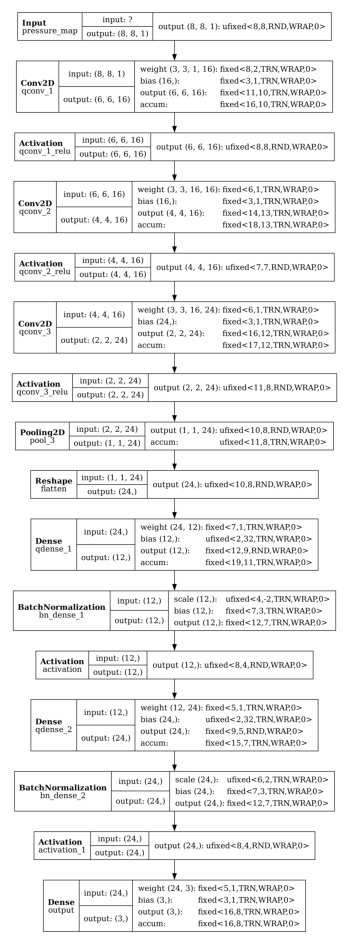

In [11]:
hls4ml.utils.plot_model(hls_model, to_file="figures/hls_model.png", show_shapes=True, show_precision=True, dpi=300)

plt.figure(figsize=(12, 12))
plt.imshow(plt.imread("figures/hls_model.png"))
plt.axis("off")
plt.show()

In [12]:
for layer in hls_model.get_layers():
    print(f"\nLayer: {layer.name} ({layer.class_name})")
    
    # Accumulator precision (e.g., for matrix multiplies / convolutions)
    accum_t = layer.get_attr('accum_t')
    if accum_t is not None:
        print(f"  accum_t:  {accum_t.precision}")
    
    # Weights & biases
    for w_name, w_var in layer.weights.items():
        print(f"  {w_name}: {w_var.type.precision}")
    
    # Output / intermediate tensors
    for v_name, v_var in layer.variables.items():
        print(f"  {v_name}: {v_var.type.precision}")


Layer: pressure_map (Input)
  pressure_map: ufixed<8,8,RND,WRAP,0>

Layer: qconv_1 (Conv2D)
  accum_t:  fixed<16,10,TRN,WRAP,0>
  weight: fixed<8,2,TRN,WRAP,0>
  bias: fixed<3,1,TRN,WRAP,0>
  qconv_1: fixed<11,10,TRN,WRAP,0>

Layer: qconv_1_relu (Activation)
  qconv_1_relu: ufixed<8,8,RND,WRAP,0>

Layer: qconv_2 (Conv2D)
  accum_t:  fixed<18,13,TRN,WRAP,0>
  weight: fixed<6,1,TRN,WRAP,0>
  bias: fixed<3,1,TRN,WRAP,0>
  qconv_2: fixed<14,13,TRN,WRAP,0>

Layer: qconv_2_relu (Activation)
  qconv_2_relu: ufixed<7,7,RND,WRAP,0>

Layer: qconv_3 (Conv2D)
  accum_t:  fixed<17,12,TRN,WRAP,0>
  weight: fixed<6,1,TRN,WRAP,0>
  bias: fixed<3,1,TRN,WRAP,0>
  qconv_3: fixed<16,12,TRN,WRAP,0>

Layer: qconv_3_relu (Activation)
  qconv_3_relu: ufixed<11,8,RND,WRAP,0>

Layer: pool_3 (Pooling2D)
  accum_t:  ufixed<11,8,TRN,WRAP,0>
  pool_3: ufixed<10,8,RND,WRAP,0>

Layer: flatten (Reshape)
  flatten: ufixed<10,8,RND,WRAP,0>

Layer: qdense_1 (Dense)
  accum_t:  fixed<19,11,TRN,WRAP,0>
  weight: fixed<7,1

### Evaluation

In [13]:
# From part4.1_HG_quantization and larger_jet_tagger
X_test = np.ascontiguousarray(X_test)

# From Scr_2_HLS4ML_Vivado_generator
y_hls = hls_model.predict(X_test) # Executes the FPGA firmware with bit-accurate emulation on the CPU.
y_hls_prob = softmax(y_hls, axis=1) # Convert logits to probabilities for log_loss

# Calculating accuracy and crossentropy loss of HLS_model
hls_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))
hls_crossentropyloss = log_loss(y_true=y_test, y_pred=y_hls_prob)
metrics_tuple = (hls_crossentropyloss, hls_accuracy)

## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)
print("HLS4ML model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(metrics_tuple[0], metrics_tuple[1]*100))    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

HLS4ML model evaluation 	 Loss: 0.29 	 Accuracy: 88.53%
Keras  model evaluation 	 Loss: 0.30 	 Accuracy: 88.53%


In [14]:
# Run prediction
y_keras = model_qat.predict(X_test, batch_size=2048)

# Test for mismatches
# HGQ2 and hls4ml should produce the same output, up to machine precision
# Notice that due to the quantization, internal mismatches may be amplified, but the vast majority of the output should match
print(f"{np.sum(y_keras != y_hls)} / {np.prod(y_keras.shape)} value mismatches")

59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step
0 / 360003 value mismatches


## Building

### Soft IP

In [15]:
# Build with various options
if BUILD_IP:
    report = hls_model.build(
        reset=RESET_BUILD,       # Reset project before build
        csim=True,          # Run C simulation
        synth=True,         # Run HLS synthesis
        # cosim=True,       # Run co-simulation
        # validation=False, # Run validation
        export=True,        # Export IP
        vsynth=False,       # Run Vivado synthesis
        fifo_opt=True       # FIFO optimization
    )


****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Tue Jun 30 21:36:31 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/jeison/Nextcloud/PUCMM/ProyectoGrado/soft_ip/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project -reset myproject_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Opening and resetting solution '/home/jeison/Nextcloud/PUCMM/ProyectoGrado/soft_ip/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_t

### Report

In [16]:
if BUILD_IP:
    # Latency (cycles)
    best_latency = int(report['CSynthesisReport']['BestLatency'])
    worst_latency = int(report['CSynthesisReport']['WorstLatency'])
    print(f"Latency: {best_latency} - {worst_latency} cycles")

    # Clock (ns)
    target_clock = float(report['CSynthesisReport']['TargetClockPeriod'])
    estimated_clock = float(report['CSynthesisReport']['EstimatedClockPeriod'])
    print(f"Target Clock = {target_clock} ns | Estimated Clock = {estimated_clock} ns")

    # Available resources
    avail_LUT = int(report['CSynthesisReport']['AvailableLUT'])
    avail_FF = int(report['CSynthesisReport']['AvailableFF'])
    avail_DSP = int(report['CSynthesisReport']['AvailableDSP'])
    avail_BRAM = int(report['CSynthesisReport']['AvailableBRAM_18K'])

    # Used resources (Vitis HLS)
    used_LUT = int(report['CSynthesisReport']['LUT'])
    used_FF = int(report['CSynthesisReport']['FF'])
    used_DSP = int(report['CSynthesisReport']['DSP'])
    used_BRAM = int(report['CSynthesisReport']['BRAM_18K'])

    # Calculate percentages
    used_LUT_pct = (used_LUT / avail_LUT) * 100
    used_FF_pct = (used_FF / avail_FF) * 100
    used_DSP_pct = (used_DSP / avail_DSP) * 100
    used_BRAM_pct = (used_BRAM / avail_BRAM) * 100

    # Vitis HLS Resources
    print(f"\n--- Vitis HLS Resource Utilization ---")
    print(f"LUT:  {used_LUT:>6} / {avail_LUT:>6} ({used_LUT_pct:>5.2f}%)")
    print(f"FF:   {used_FF:>6} / {avail_FF:>6} ({used_FF_pct:>5.2f}%)")
    print(f"DSP:  {used_DSP:>6} / {avail_DSP:>6} ({used_DSP_pct:>5.2f}%)")
    print(f"BRAM: {used_BRAM:>6} / {avail_BRAM:>6} ({used_BRAM_pct:>5.2f}%)")

    # Used resources (Vivado)
    used_LUT_v = int(report['VivadoSynthReport']['LUT'])
    used_FF_v = int(report['VivadoSynthReport']['FF'])
    used_DSP_v = int(report['VivadoSynthReport']['DSP48E'])
    # used_BRAM_v = int(report['VivadoSynthReport']['BRAM_18K'])

    # Calculate percentages
    used_LUT_v_pct = (used_LUT_v / avail_LUT) * 100
    used_FF_v_pct = (used_FF_v / avail_FF) * 100
    used_DSP_v_pct = (used_DSP_v / avail_DSP) * 100
    # used_BRAM_v_pct = (used_BRAM_v / avail_BRAM) * 100

    # Vivado Synthesis Resources
    print(f"\n--- Vivado Synthesis Resource Utilization ---")
    print(f"LUT:  {used_LUT_v:>6} / {avail_LUT:>6} ({used_LUT_v_pct:>5.2f}%)")
    print(f"FF:   {used_FF_v:>6} / {avail_FF:>6} ({used_FF_v_pct:>5.2f}%)")
    print(f"DSP:  {used_DSP_v:>6} / {avail_DSP:>6} ({used_DSP_v_pct:>5.2f}%)")
    # print(f"BRAM: {used_BRAM_v:>6} / {avail_BRAM:>6} ({used_BRAM_v_pct:>5.2f}%)")

Latency: 5399 - 5449 cycles
Target Clock = 10.0 ns | Estimated Clock = 10.259 ns

--- Vitis HLS Resource Utilization ---
LUT:   40214 /  53200 (75.59%)
FF:    22980 / 106400 (21.60%)
DSP:      59 /    220 (26.82%)
BRAM:     87 /    280 (31.07%)

--- Vivado Synthesis Resource Utilization ---
LUT:  102239 /  53200 (192.18%)
FF:    80889 / 106400 (76.02%)
DSP:       1 /    220 ( 0.45%)


### Pynq-Z2

In [18]:
# Build manually bitstream for pynq-z2
if BUILD_PYNQ:
    repo_root = Path.cwd().parent
    vitis_dir = repo_root / 'vitis_pynq'
    vivado_dir = repo_root / 'vivado_pynq'

    # Clean previous build artifacts if requested
    if RESET_BUILD:
        for build_dir in [
            vitis_dir / 'myproject_axi_prj',
            vivado_dir / 'myproject_vivado_accelerator',
        ]:
            if build_dir.exists():
                print(f'Removing {build_dir}')
                shutil.rmtree(build_dir)

    # Step 1: Synthesize AXI-Stream wrapper with Vitis HLS
    print('--- Running Vitis HLS wrapper synthesis ---')
    hls_result = subprocess.run(
        ['vitis-run', '--mode', 'hls', '--tcl', str(vitis_dir / 'run_hls.tcl')],
        capture_output=True,
        text=True,
        cwd=str(vitis_dir),
    )
    print(hls_result.stdout)
    if hls_result.returncode != 0:
        print('ERROR: Vitis HLS synthesis failed')
        print(hls_result.stderr)
    else:
        print('Vitis HLS synthesis completed successfully.')

    # Step 2: Generate bitstream with Vivado
    print('--- Running Vivado bitstream generation ---')
    vivado_result = subprocess.run(
        ['vivado', '-mode', 'batch', '-source', 'axi_stream_design.tcl'],
        capture_output=True,
        text=True,
        cwd=str(vivado_dir),
    )
    print(vivado_result.stdout)
    if vivado_result.returncode != 0:
        print('ERROR: Vivado bitstream generation failed')
        print(vivado_result.stderr)
    else:
        print('Vivado bitstream generation completed successfully.')

Removing /home/jeison/Nextcloud/PUCMM/ProyectoGrado/vitis_pynq/myproject_axi_prj
Removing /home/jeison/Nextcloud/PUCMM/ProyectoGrado/vivado_pynq/myproject_vivado_accelerator
--- Running Vitis HLS wrapper synthesis ---

****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Tue Jun 30 22:54:05 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/jeison/Nextcloud/PUCMM/ProyectoGrado/vitis_pynq/run_hls.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_axi_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Creating and opening solution '/home/jeison/Nextcloud/PUCMM/ProyectoGrado/vitis_pynq/myproject_axi_prj'.
INFO: [HLS 200-1510] Running: set_top mypro